In [ ]:
### Please, find the short report with comments here: https://docs.google.com/document/d/1e7mfdjFv9fqJcq-vEOMAfMto0NPxZKq7QhZq2WRkr-s/edit?usp=sharing


import pandas as pd
import numpy as np
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt

from skbio.diversity import alpha
from skbio.diversity import beta_diversity
from scipy.stats import mannwhitneyu
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

from statsmodels.stats.multitest import multipletests

## Metadata clean-up

In [2]:
metadata = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW2/input/human_core_long.tsv', sep='\t')
metadata.info()
metadata.tail()

<class 'pandas.DataFrame'>
RangeIndex: 2837472 entries, 0 to 2837471
Data columns (total 4 columns):
 #   Column         Dtype
---  ------         -----
 0   sample_alias   str  
 1   metadata_item  str  
 2   curation_tier  str  
 3   value          str  
dtypes: str(4)
memory usage: 86.6 MB


,sample_alias,metadata_item,curation_tier,value
2837467,Davies_2022_travellers.S025_T1,doi,core,10.1080/19490976.2022.2060676
2837468,Davies_2022_travellers.S025_T1,timeseries_available,core,yes
2837469,Davies_2022_travellers.S025_T1,timeseries_count,core,2
2837470,Davies_2022_travellers.S025_T1,timeseries_duration,core,35
2837471,Davies_2022_travellers.S025_T1,location,core,"Netherlands: Amsterdam, Maastricht, or Rotterdam"


In [3]:
metadata_wide = metadata.pivot(
    index='sample_alias', 
    columns='metadata_item', 
    values='value'
).reset_index()
print(metadata_wide.columns)
metadata_wide.head()

Index(['sample_alias', 'age_category', 'age_range', 'age_years', 'artificial',
       'available_info', 'bmi', 'collection_date', 'collection_date_end',
       'diet', 'doi', 'environment_biome', 'environment_feature',
       'environment_material', 'environmental_package', 'geographic_location',
       'height_cm', 'intervention', 'last_change', 'latitude', 'location',
       'location_resolution', 'longitude', 'medication',
       'medication_with_parents', 'pmid', 'sex', 'smoker', 'spire_sample_name',
       'study_code', 'subject_disease_status', 'subject_id', 'tax_id',
       'timepoint', 'timeseries_available', 'timeseries_count',
       'timeseries_duration', 'type_of_birth', 'weight_kg'],
      dtype='str', name='metadata_item')


metadata_item,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,study_code,subject_disease_status,subject_id,tax_id,timepoint,timeseries_available,timeseries_count,timeseries_duration,type_of_birth,weight_kg
0,Aggarwala_2020_FMT_RCDI.sample_1001095A,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,ulcerative colitis,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,0,yes,7,1825,NaN,NaN
1,Aggarwala_2020_FMT_RCDI.sample_1001095F,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,7,yes,7,1825,NaN,NaN
2,Aggarwala_2020_FMT_RCDI.sample_1001095G,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,33,yes,7,1825,NaN,NaN
3,Aggarwala_2020_FMT_RCDI.sample_1001095H,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,81,yes,7,1825,NaN,NaN
4,Aggarwala_2020_FMT_RCDI.sample_1001095I,adult,adult,NaN,NaN,NaN,NaN,2000-01-01,2020-12-31,NaN,...,Aggarwala_2020_FMT_RCDI,NaN,Aggarwala_2020_FMT_RCDI.subject_1001095,408170,427,yes,7,1825,NaN,NaN


In [4]:
disease_counts = metadata_wide['subject_disease_status'].value_counts()
print(disease_counts.head(20))

subject_disease_status
COHORT                             50980
CTR                                13283
type 2 diabetes                     2326
critically ill patient              1893
Crohn's disease                     1682
ulcerative colitis                  1679
multiple sclerosis                  1635
cystic fibrosis                     1252
Parkinson's disease                 1220
colorectal cancer                   1159
melanoma                             809
Clostridium difficile infection      786
COVID-19                             592
kidney transplant recipient          508
HIV                                  488
metabolic syndrome                   472
control patient                      452
alcoholic liver cirrhosis            439
irritable bowel syndrome             428
severe acute malnutrition            388
Name: count, dtype: int64


In [5]:
cron_ctr_df = metadata_wide[metadata_wide['subject_disease_status'].isin(['Crohn\'s disease', 'CTR'])].copy()
cron_clean = cron_ctr_df.drop_duplicates(subset=['subject_id', 'timepoint', 'age_years']) #since we have duplicates for metadata profiles, we have to keep only one unique sample

cron_clean = cron_clean[cron_clean['sex'].isin(['male', 'female'])] #filter sex
cron_clean = cron_clean[cron_clean['age_category'].str.lower().isin(['adolescent', 'adult'])] #filter age_category
cron_clean = cron_clean[cron_clean['environment_material'] == 'fecal material [ENVO:00002003]'] #filter material source

final_dist = pd.crosstab(cron_clean['subject_disease_status'], 
                         [cron_clean['age_category'], cron_clean['sex']], 
                         margins=True)

print("\n--- Final Research Cohort Distribution ---")
display(final_dist)

cron_final = cron_clean.reset_index(drop=True)
cron_final.tail()


--- Final Research Cohort Distribution ---


age_category           adolescent       adult         All
sex                        female male female  male      
subject_disease_status                                   
CTR                            53   52   2987  2828  5920
Crohn's disease                85  166    387   357   995
All                           138  218   3374  3185  6915

metadata_item,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,study_code,subject_disease_status,subject_id,tax_id,timepoint,timeseries_available,timeseries_count,timeseries_duration,type_of_birth,weight_kg
6910,Zuo_2020_COVID.C5,adult,NaN,49,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,Zuo_2020_COVID,CTR,Zuo_2020_COVID.C5,408170,0,no,1,0,NaN,NaN
6911,Zuo_2020_COVID.C6,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,Zuo_2020_COVID,CTR,Zuo_2020_COVID.C6,408170,0,no,1,0,NaN,NaN
6912,Zuo_2020_COVID.C7,adult,NaN,22,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,Zuo_2020_COVID,CTR,Zuo_2020_COVID.C7,408170,0,no,1,0,NaN,NaN
6913,Zuo_2020_COVID.C8,adult,NaN,35,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,Zuo_2020_COVID,CTR,Zuo_2020_COVID.C8,408170,0,no,1,0,NaN,NaN
6914,Zuo_2020_COVID.C9,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,Zuo_2020_COVID,CTR,Zuo_2020_COVID.C9,408170,0,no,1,0,NaN,NaN


In [6]:
cron_final.head()

metadata_item,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,study_code,subject_disease_status,subject_id,tax_id,timepoint,timeseries_available,timeseries_count,timeseries_duration,type_of_birth,weight_kg
0,Al_2023_kidneystone.450,adult,NaN,69,NaN,NaN,39.2,2015-08-01,2019-01-31,NaN,...,Al_2023_kidneystone,CTR,Al_2023_kidneystone.450,408170,0,no,1,0,NaN,113
1,Al_2023_kidneystone.451,adult,NaN,69,NaN,NaN,27,2015-08-01,2019-01-31,NaN,...,Al_2023_kidneystone,CTR,Al_2023_kidneystone.451,408170,0,no,1,0,NaN,73
2,Al_2023_kidneystone.452,adult,NaN,59,NaN,NaN,30,2015-08-01,2019-01-31,NaN,...,Al_2023_kidneystone,CTR,Al_2023_kidneystone.452,408170,0,no,1,0,NaN,95
3,Al_2023_kidneystone.453,adult,NaN,55,NaN,NaN,25.5,2015-08-01,2019-01-31,NaN,...,Al_2023_kidneystone,CTR,Al_2023_kidneystone.453,408170,0,no,1,0,NaN,76
4,Al_2023_kidneystone.454,adult,NaN,61,NaN,NaN,24,2015-08-01,2019-01-31,NaN,...,Al_2023_kidneystone,CTR,Al_2023_kidneystone.454,408170,0,no,1,0,NaN,59


## Abundance table clean-up

In [7]:
abundance_df = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW2/input/human_metaphlan4_species_2026-02-15.tsv', sep='\t')

In [8]:
abundance_df.head()

,sample_alias,species,rel_abund
0,Cait_2019_infant.sample_AC114,s__Bacteroides_ovatus,0.00116
1,Cait_2019_infant.sample_AC114,s__Staphylococcus_epidermidis,0.00119
2,Cait_2019_infant.sample_AC114,s__Bacteroides_fragilis,0.00278
3,Cait_2019_infant.sample_AC114,s__Parabacteroides_distasonis,0.00315
4,Cait_2019_infant.sample_AC114,s__Veillonella_dispar,0.00370


In [9]:
# crashes my laptop
# matrix_df_1 = abundance_df.pivot(
#     index='sample_alias', 
#     columns='species', 
#     values='rel_abund'
# ).fillna(0)

In [10]:
target_samples = cron_clean['sample_alias'].unique() # since my computer cannot process the whole abundance table, I have filtered the ones I need only
abundance_filtered = abundance_df[abundance_df['sample_alias'].isin(target_samples)].copy()

print(abundance_filtered['sample_alias'].nunique()) # it seems that some of the samples has no information in abundance table
print(cron_final['sample_alias'].nunique())

matrix_df = abundance_filtered.pivot(
    index='sample_alias', 
    columns='species', 
    values='rel_abund'
).fillna(0)

print(matrix_df.index.nunique())

5150
6915
5150


In [11]:
matrix_df.head()

species,s__Abiotrophia_defectiva,s__Abiotrophia_sp_HMSC24B09,s__Absicoccus_porci,s__Acetivibrio_sp_MSJd_27,s__Achromobacter_insuavis,s__Achromobacter_xylosoxidans,s__Acidaminococcus_SGB42794,s__Acidaminococcus_SGB53443,s__Acidaminococcus_SGB5735,s__Acidaminococcus_fermentans,...,s__Zhenhengia_yiwuensis,s__Zhenpiania_hominis,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont
sample_alias,,,,,,,,,,,,,,,,,,,,,
Bai_2021_HIV.Q_H1,0.0,0.0,0.0,0.02586,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.01139,0.0,0.0,0.0,0.04481,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H10,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00124,0.0,0.0,0.0,0.02576,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H11,0.0,0.0,0.0,0.01715,0.0,0.0,0.0,0.0,0.0,0.81517,...,0.0,0.01607,0.0,0.0,0.0,0.03737,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H2,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00944,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
Bai_2021_HIV.Q_H3,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.00000,0.0,0.0,0.0,0.03074,0.0,0.0,0.0,0.0


In [12]:
matrix_df.columns

Index(['s__Abiotrophia_defectiva', 's__Abiotrophia_sp_HMSC24B09',
       's__Absicoccus_porci', 's__Acetivibrio_sp_MSJd_27',
       's__Achromobacter_insuavis', 's__Achromobacter_xylosoxidans',
       's__Acidaminococcus_SGB42794', 's__Acidaminococcus_SGB53443',
       's__Acidaminococcus_SGB5735', 's__Acidaminococcus_fermentans',
       ...
       's__Zhenhengia_yiwuensis', 's__Zhenpiania_hominis',
       's__Zongyangia_hominis', 's__bacterium_1XD42_54',
       's__bacterium_210820_DFI_6_37', 's__bacterium_210917_DFI_7_65',
       's__bacterium_210917_SL_2_15', 's__bacterium_D16_34',
       's__bacterium_OL_1', 's__unidentified_bacterial_endosymbiont'],
      dtype='str', name='species', length=3787)

## Metadata and abundance merge

In [13]:
final_combined_df = pd.merge(
    cron_final, 
    matrix_df,
    left_on='sample_alias', 
    right_index=True, 
    how='inner'
)
print(len(final_combined_df['sample_alias']))

print(f"Total columns: {len(final_combined_df.columns)}")
final_combined_df = final_combined_df.reset_index(drop=True)
final_combined_df.head()

5150
Total columns: 3826


,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__Zhenhengia_yiwuensis,s__Zhenpiania_hominis,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont
0,Bai_2021_HIV.Q_H1,adult,NaN,29,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.01139,0.0,0.0,0.0,0.04481,0.0,0.0,0.0,0.0
1,Bai_2021_HIV.Q_H10,adult,NaN,33,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.00124,0.0,0.0,0.0,0.02576,0.0,0.0,0.0,0.0
2,Bai_2021_HIV.Q_H11,adult,NaN,30,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.01607,0.0,0.0,0.0,0.03737,0.0,0.0,0.0,0.0
3,Bai_2021_HIV.Q_H2,adult,NaN,35,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.00944,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
4,Bai_2021_HIV.Q_H3,adult,NaN,51,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.00000,0.0,0.0,0.0,0.03074,0.0,0.0,0.0,0.0


In [15]:
final_combined_df.tail()

,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__Zhenpiania_hominis,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont,total_counts
5145,Zuo_2020_COVID.C5,adult,NaN,49,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.17077,0.0,0.0,0.0,0.01797,0.0,0.0,0.47820,0.0,99.99995
5146,Zuo_2020_COVID.C6,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.00088,0.0,0.0,0.0,0.22353,0.0,0.0,0.00000,0.0,99.99997
5147,Zuo_2020_COVID.C7,adult,NaN,22,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.00000,0.0,0.0,0.0,0.04626,0.0,0.0,0.00000,0.0,99.99996
5148,Zuo_2020_COVID.C8,adult,NaN,35,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.01994,0.0,0.0,0.0,0.00000,0.0,0.0,0.00000,0.0,100.00000
5149,Zuo_2020_COVID.C9,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.02013,0.0,0.0,0.0,0.09882,0.0,0.0,0.21168,0.0,100.00001


In [18]:
# Verify if every row is a unique sample
is_unique = final_combined_df['sample_alias'].is_unique
print(f"Is every sample alias unique? {is_unique}")

if not is_unique:
    print(f"Duplicates found: {final_combined_df['sample_alias'].duplicated().sum()}")

Is every sample alias unique? True


In [19]:
final_combined_df.to_csv('merged_samples.csv', index=False)

## Alpha-diversity analysis (shannon)

In [20]:
df = final_combined_df
groups = df['subject_disease_status'].unique()
print(f"Available groups: {groups}")

Available groups: <StringArray>
['CTR', 'Crohn's disease']
Length: 2, dtype: str


In [21]:
bacteria_cols = [col for col in df.columns if col.startswith('s__')]
df['shannon_index'] = df[bacteria_cols].apply(lambda x: alpha.shannon(x), axis=1)

In [22]:
df.head()

,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__Zongyangia_hominis,s__bacterium_1XD42_54,s__bacterium_210820_DFI_6_37,s__bacterium_210917_DFI_7_65,s__bacterium_210917_SL_2_15,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont,total_counts,shannon_index
0,Bai_2021_HIV.Q_H1,adult,NaN,29,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.0,0.0,0.04481,0.0,0.0,0.0,0.0,99.99998,4.198041
1,Bai_2021_HIV.Q_H10,adult,NaN,33,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.0,0.0,0.02576,0.0,0.0,0.0,0.0,100.00000,3.670945
2,Bai_2021_HIV.Q_H11,adult,NaN,30,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.0,0.0,0.03737,0.0,0.0,0.0,0.0,100.00012,4.139675
3,Bai_2021_HIV.Q_H2,adult,NaN,35,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,99.99992,3.800355
4,Bai_2021_HIV.Q_H3,adult,NaN,51,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,0.0,0.0,0.0,0.03074,0.0,0.0,0.0,0.0,99.99988,3.505637


In [23]:
ctr = df[df['subject_disease_status'] == 'CTR']['shannon_index']
cd = df[df['subject_disease_status'] == "Crohn's disease"]['shannon_index']

In [24]:
stat, p_val = mannwhitneyu(ctr, cd)
print(f"Mann-Whitney U p-value: {p_val:.2e}")

Mann-Whitney U p-value: 2.95e-191


/tmp/ipykernel_19762/4078355605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19762/4078355605.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


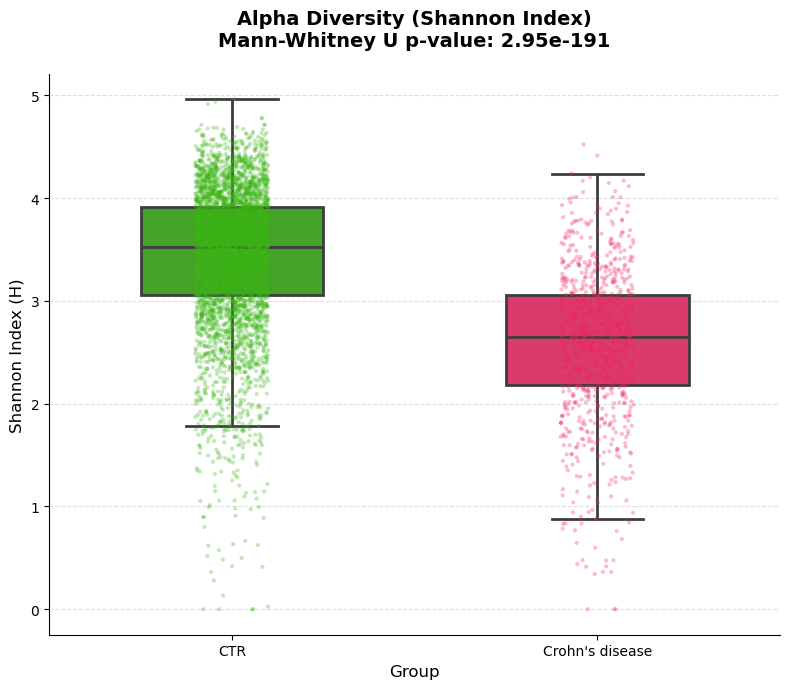

In [25]:
my_palette = {"CTR": "#3ab614", "Crohn's disease": "#f32261"}
plt.figure(figsize=(8, 7))
sns.boxplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=df, 
    palette=my_palette,
    showfliers=False, 
    width=0.5,
    linewidth=2
)

sns.stripplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=df, 
    palette=my_palette,
    size=3, 
    alpha=0.3,    # High transparency to handle 5k+ points
    jitter=True, 
    dodge=False
)

plt.title(f'Alpha Diversity (Shannon Index)\nMann-Whitney U p-value: {p_val:.2e}', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Shannon Index (H)', fontsize=12)
plt.xlabel('Group', fontsize=12)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

In [26]:
ctr_adult_df = df[(df['subject_disease_status'] == 'CTR') & (df['age_category'] == 'adult')]
ctr_adol_df  = df[(df['subject_disease_status'] == 'CTR') & (df['age_category'] == 'adolescent')]

cd_adult_df  = df[(df['subject_disease_status'] == "Crohn's disease") & (df['age_category'] == 'adult')]
cd_adol_df   = df[(df['subject_disease_status'] == "Crohn's disease") & (df['age_category'] == 'adolescent')]

print(f"CTR Adults: {len(ctr_adult_df)}")
print(f"CTR Adolescents: {len(ctr_adol_df)}")
print(f"Crohn's Adults: {len(cd_adult_df)}")
print(f"Crohn's Adolescents: {len(cd_adol_df)}")

CTR Adults: 4163
CTR Adolescents: 96
Crohn's Adults: 641
Crohn's Adolescents: 250


In [28]:
ctr_adult_shannon = ctr_adult_df['shannon_index']
ctr_adol_shannon  = ctr_adol_df['shannon_index']
cd_adult_shannon  = cd_adult_df['shannon_index']
cd_adol_shannon   = cd_adol_df['shannon_index']

In [29]:
stat, p_adol = mannwhitneyu(ctr_adol_shannon, cd_adol_shannon)
print(f"Adolescent comparison p-value: {p_adol:.2e}")

stat, p_adult = mannwhitneyu(ctr_adult_shannon, cd_adult_shannon)
print(f"Adult comparison p-value: {p_adult:.2e}")

Adolescent comparison p-value: 5.55e-29
Adult comparison p-value: 4.20e-124


/tmp/ipykernel_19762/1258655148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19762/1258655148.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


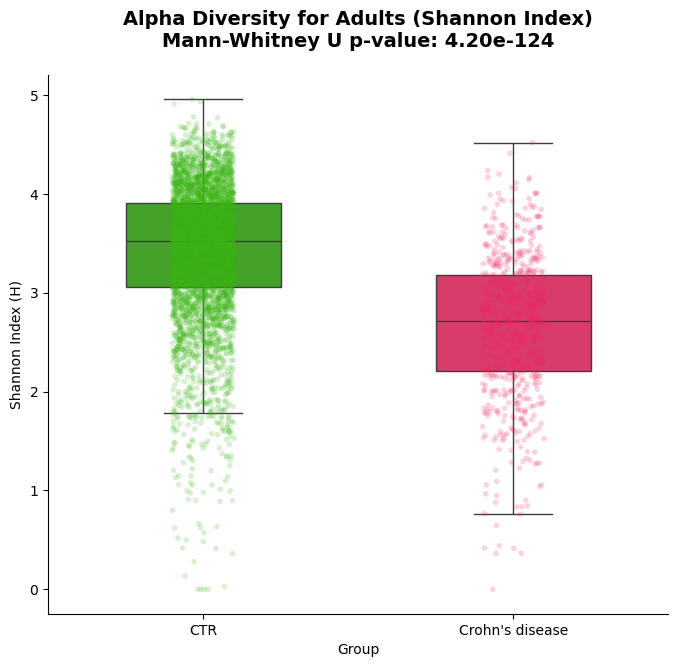

In [30]:
plot_df_adult = df[((df['age_category'] == 'adult') & df['subject_disease_status'].isin(['CTR', "Crohn's disease"]))]

plt.figure(figsize=(8, 7))
my_colors = {"CTR": "#3ab614", "Crohn's disease": "#f32261"}

sns.boxplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=plot_df_adult, 
    palette=my_colors,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=plot_df_adult, 
    palette=my_colors,
    size=4, 
    alpha=0.2, 
    jitter=True
)

plt.title(f'Alpha Diversity for Adults (Shannon Index)\nMann-Whitney U p-value: {p_adult:.2e}', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Shannon Index (H)')
plt.xlabel('Group')
sns.despine()
plt.show()

/tmp/ipykernel_19762/1645981635.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19762/1645981635.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


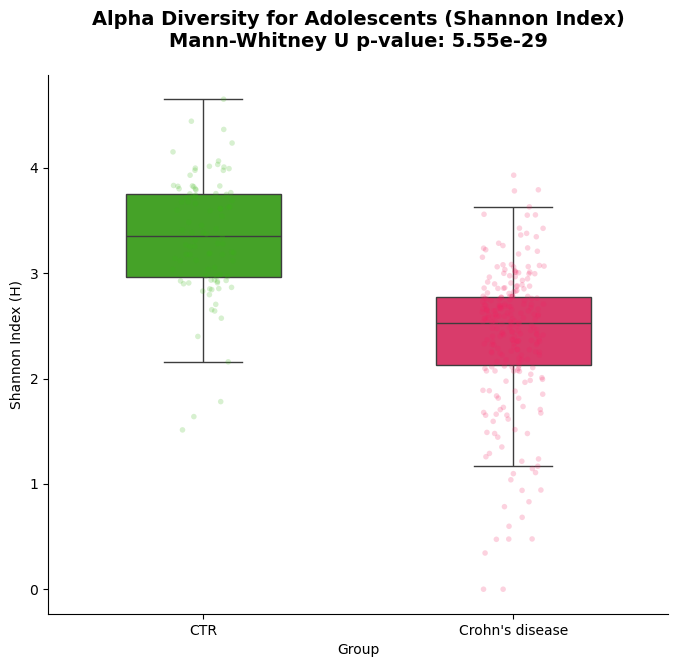

In [31]:
plot_df_adol = df[((df['age_category'] == 'adolescent') & df['subject_disease_status'].isin(['CTR', "Crohn's disease"]))]

plt.figure(figsize=(8, 7))
my_colors = {"CTR": "#3ab614", "Crohn's disease": "#f32261"}

sns.boxplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=plot_df_adol, 
    palette=my_colors,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    x='subject_disease_status', 
    y='shannon_index', 
    data=plot_df_adol, 
    palette=my_colors,
    size=4, 
    alpha=0.2, 
    jitter=True
)

plt.title(f'Alpha Diversity for Adolescents (Shannon Index)\nMann-Whitney U p-value: {p_adol:.2e}', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Shannon Index (H)')
plt.xlabel('Group')
sns.despine()
plt.show()

## Beta-diversity analysis

In [47]:
# Keep species present in at least 5% of samples
prevalence = (df[bacteria_cols] > 0).mean() * 100
mean_abundance = df[bacteria_cols].mean()

to_keep = prevalence[(prevalence >= 5) & (mean_abundance >= 0.01)].index.tolist()

In [48]:
# 1. Species Filtering (Your existing logic)
prevalence = (df[bacteria_cols] > 0).mean() * 100
mean_abundance = df[bacteria_cols].mean()

to_keep = prevalence[(prevalence >= 5) & (mean_abundance >= 0.01)].index.tolist()

# 2. Sample Quality Check (The 'Mass Loss' filter)
# Calculate how much of the original 100% is left after keeping only 'to_keep'
df['core_total'] = df[to_keep].sum(axis=1)

# IMPORTANT: Check if your data is 0-1 or 0-100
# If median is < 1, we use 0.75. If median is > 1, we use 75.
threshold = 75 if df['core_total'].median() > 1 else 0.75

df_clean = df[df['core_total'] >= threshold].copy()

print(f"Species retained: {len(to_keep)}")
print(f"Samples retained: {len(df_clean)} (Out of {len(df)})")

Species retained: 414
Samples retained: 4710 (Out of 5150)


In [49]:
species_data = df_clean[to_keep].values
sample_ids = df_clean['sample_alias'].tolist()
print(f"Final matrix shape: {species_data.shape}")

Final matrix shape: (4710, 414)


In [51]:
bc_dm = beta_diversity("braycurtis", species_data, ids=sample_ids)
pcoa_results = pcoa(bc_dm)
df_clean['PC1'] = pcoa_results.samples['PC1'].values
df_clean['PC2'] = pcoa_results.samples['PC2'].values

/home/valerie/micromamba/envs/metagenomics/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/valerie/micromamba/envs/metagenomics/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -3.353092325771442 whereas the largest positive one is 165.11802245911767.
  warn(


In [52]:
# Use .iloc to access by position (0 for the first axis, 1 for the second)
pc1_var = pcoa_results.proportion_explained.iloc[0] * 100
pc2_var = pcoa_results.proportion_explained.iloc[1] * 100

print(f"PC1 explains {pc1_var:.2f}% of the variance.")
print(f"PC2 explains {pc2_var:.2f}% of the variance.")

PC1 explains 7.34% of the variance.
PC2 explains 5.09% of the variance.


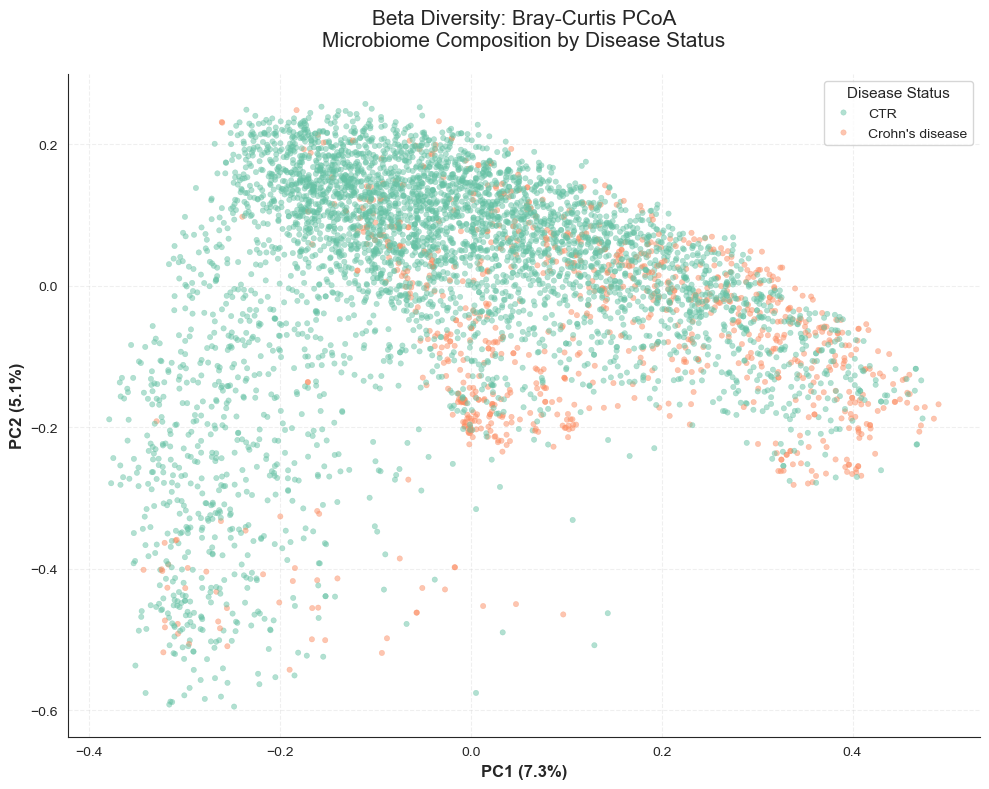

In [53]:
sns.set_style("white")
plt.figure(figsize=(10, 8))

my_palette = {"CTR": "#66c2a5", "Crohn's disease": "#fc8d62"}

# 3. Create the scatter plot
sns.scatterplot(
    data=df, 
    x='PC1', 
    y='PC2', 
    hue='subject_disease_status', 
    palette=my_palette,
    alpha=0.5,      
    s=15,           
    edgecolor=None  
)

plt.xlabel(f"PC1 ({pc1_var:.1f}%)", fontsize=12, fontweight='bold')
plt.ylabel(f"PC2 ({pc2_var:.1f}%)", fontsize=12, fontweight='bold')

plt.title("Beta Diversity: Bray-Curtis PCoA\nMicrobiome Composition by Disease Status", 
          fontsize=15, pad=20)

plt.legend(title="Disease Status", title_fontsize='11', loc='upper right', frameon=True)
sns.despine()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
# plt.savefig('pcoa_disease_clusters.png', dpi=300)
plt.show()

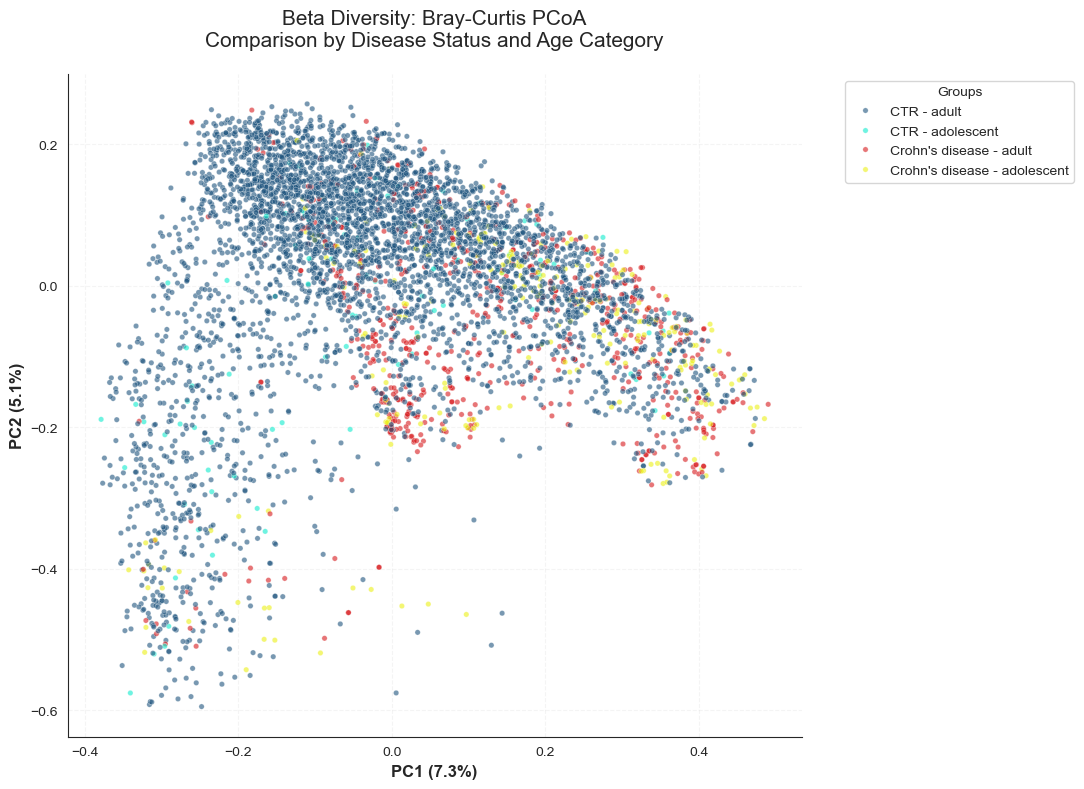

In [54]:
df['group_combined'] = df['subject_disease_status'] + " - " + df['age_category']

subgroup_palette = {
    "CTR - adult": "#1e547e",            # Strong Blue
    "CTR - adolescent": "#0febcd",       # Light Blue
    "Crohn's disease - adult": "#d7191c", # Strong Red/Orange
    "Crohn's disease - adolescent": "#ecf016" # Light Orange
}

plt.figure(figsize=(11, 8))


sns.scatterplot(
    data=df, 
    x='PC1', 
    y='PC2', 
    hue='group_combined', 
    palette=subgroup_palette,
    alpha=0.6,      # Slightly higher alpha to see the smaller adolescent groups
    s=15,           # Slightly larger dots
    edgecolor='w',  # White edge makes overlapping dots distinct
    linewidth=0.3
)


plt.xlabel(f"PC1 ({pc1_var:.1f}%)", fontsize=12, fontweight='bold')
plt.ylabel(f"PC2 ({pc2_var:.1f}%)", fontsize=12, fontweight='bold')
plt.title("Beta Diversity: Bray-Curtis PCoA\nComparison by Disease Status and Age Category", 
          fontsize=15, pad=20)

plt.legend(title="Groups", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
sns.despine()
plt.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
# plt.savefig('pcoa_age_disease_subgroups.png', dpi=300)
plt.show()

## Differential abundance

In [ ]:
# 1. Use the Cleaned Dataframe
# We assume df_clean and to_keep were defined in your previous cleaning step
target_species = to_keep 

# 2. Extract Study ID (Applied to the cleaned data)
# This handles the 'Aggarwala_2020' format
df_clean['study_id'] = df_clean['sample_alias'].str.split('_').take(range(2)).str.join('_')

results = []
pseudocount = 1e-6

for s in target_species:
    # We pull from df_clean now!
    vals_a = df_clean[df_clean['subject_disease_status'] == 'CTR'][s]
    vals_b = df_clean[df_clean['subject_disease_status'] == "Crohn's disease"][s]
    
    # Run Mann-Whitney U
    # Using 'two-sided' is the standard for discovery
    stat, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')
    
    # Calculate Mean Abundance and Log2 Fold Change
    mean_a, mean_b = vals_a.mean(), vals_b.mean()
    
    # Biological Significance: Direction of change
    log2fc = np.log2((mean_b + pseudocount) / (mean_a + pseudocount))
    
    results.append({
        'species': s, 
        'p_value': p, 
        'log2FC': log2fc,
        'mean_CTR': mean_a,
        'mean_CD': mean_b
    })

diff_df = pd.DataFrame(results)

# 3. Apply Bonferroni Correction on the Core Microbiome (414 tests)
_, diff_df['p_adj'], _, _ = multipletests(diff_df['p_value'], method='bonferroni')

# Set thresholds for your "Strict" logic
# P_adj < 0.001 is mathematically identical to p_raw < (0.05/414)
bonferroni_raw_limit = 0.001 / len(target_species)
threshold_y = -np.log10(bonferroni_raw_limit)

print(f"Analysis complete on {len(df_clean)} high-quality samples.")
print(f"Bonferroni Raw P-value Limit: {bonferroni_raw_limit:.2e}")
print(f"Significant Species (P_adj < 0.001): {len(diff_df[diff_df['p_adj'] < 0.001])}")

Analysis complete on 4710 high-quality samples.
Bonferroni Raw P-value Limit: 2.42e-06
Significant Species (P_adj < 0.001): 329


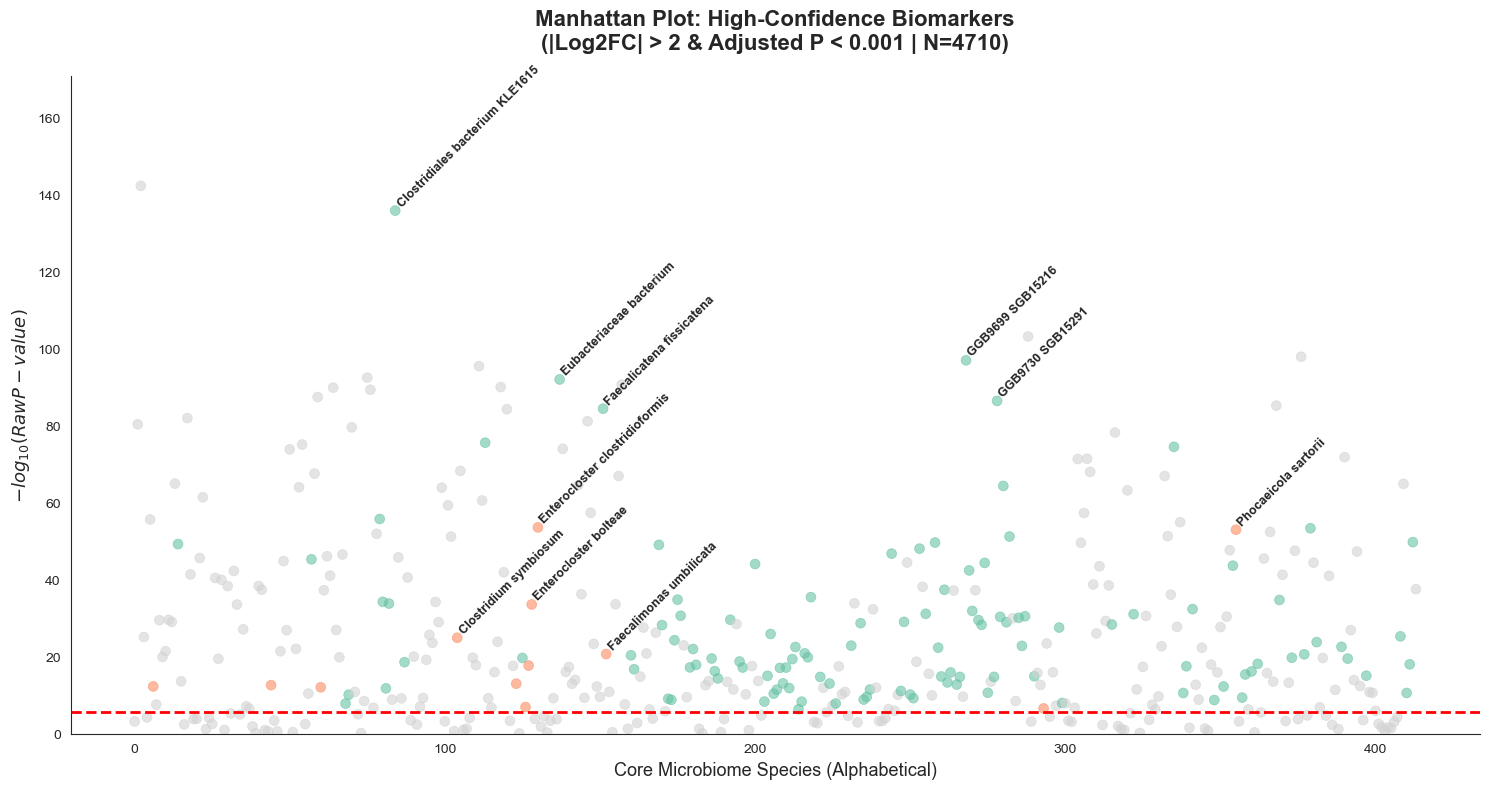

In [59]:
# 1. Prepare Plotting Data
# We use the raw p-values for the Y-axis to visualize the "Peak"
diff_df['-log10_p_raw'] = -np.log10(diff_df['p_value'])
diff_df = diff_df.sort_values('species').reset_index(drop=True)
diff_df['index'] = diff_df.index

# 2. Define the "Strict" Significance Filter
# p_adj < 0.001 (Very strict) AND |Log2FC| > 2 (4-fold change)
diff_df['is_strict'] = (diff_df['p_adj'] < 0.001) & (abs(diff_df['log2FC']) > 2)

# Color logic for the plot
diff_df['color'] = 'lightgrey'
diff_df.loc[diff_df['is_strict'] & (diff_df['log2FC'] > 0), 'color'] = '#fc8d62' # Crohn's Bloom (Salmon)
diff_df.loc[diff_df['is_strict'] & (diff_df['log2FC'] < 0), 'color'] = '#66c2a5' # CTR/Healthy (Teal)

# 3. Create the Visualization
plt.figure(figsize=(15, 8))

# Scatter plot of all 414 species
sns.scatterplot(
    data=diff_df, x='index', y='-log10_p_raw', 
    hue='color', palette={'lightgrey':'lightgrey', '#fc8d62':'#fc8d62', '#66c2a5':'#66c2a5'}, 
    legend=False, s=50, alpha=0.6, edgecolor=None
)

# 4. DRAW THE THRESHOLD LINE
# Note: Since the plot is raw p-values, we show the raw threshold 
# that corresponds to p_adj = 0.001. 
# Formula: 0.001 / 414
raw_threshold_for_line = 0.001 / len(target_species)
threshold_y = -np.log10(raw_threshold_for_line)

plt.axhline(y=threshold_y, color='red', linestyle='--', linewidth=2, zorder=5)

# 5. Label the TOP Hits (the ones that pass your strict filter)
# We will label the top 5 Salmon and top 5 Teal hits by significance
top_enriched = diff_df[diff_df['is_strict'] & (diff_df['log2FC'] > 0)].sort_values('-log10_p_raw').tail(5)
top_depleted = diff_df[diff_df['is_strict'] & (diff_df['log2FC'] < 0)].sort_values('-log10_p_raw').tail(5)

for _, row in pd.concat([top_enriched, top_depleted]).iterrows():
    name = row['species'].replace('s__', '').replace('_', ' ')
    plt.text(row['index'], row['-log10_p_raw'] + 0.5, name, 
             fontsize=9, rotation=45, ha='left', va='bottom', fontweight='bold')

# 6. Formatting
plt.title(f"Manhattan Plot: High-Confidence Biomarkers\n(|Log2FC| > 2 & Adjusted P < 0.001 | N={len(df_clean)})", 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("$-log_{10}(Raw P-value)$", fontsize=13)
plt.xlabel("Core Microbiome Species (Alphabetical)", fontsize=13)

plt.ylim(0, diff_df['-log10_p_raw'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

In [60]:
sig_stat = diff_df[diff_df['p_adj'] < 0.001]

# How many are BIOLOGICALLY significant (e.g., 4-fold change)?
sig_bio = diff_df[(diff_df['p_adj'] < 0.001) & (abs(diff_df['log2FC']) > 2)]

print(f"Statistically significant: {len(sig_stat)}")
print(f"Biologically significant (4-fold change): {len(sig_bio)}")

Statistically significant: 329
Biologically significant (4-fold change): 128


## Check what could be wrong with data

In [61]:
df.tail()

,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__bacterium_D16_34,s__bacterium_OL_1,s__unidentified_bacterial_endosymbiont,total_counts,shannon_index,PC1,PC2,core_total,zeros_count,group_combined
5145,Zuo_2020_COVID.C5,adult,NaN,49,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.0,0.47820,0.0,99.99995,4.380701,-0.178315,0.150687,78.57826,3514,CTR - adult
5146,Zuo_2020_COVID.C6,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.0,0.00000,0.0,99.99997,3.550169,0.096349,-0.001640,96.99708,3662,CTR - adult
5147,Zuo_2020_COVID.C7,adult,NaN,22,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.0,0.00000,0.0,99.99996,3.806056,-0.009293,0.119195,98.38090,3671,CTR - adult
5148,Zuo_2020_COVID.C8,adult,NaN,35,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.0,0.00000,0.0,100.00000,3.285042,0.008721,-0.008908,96.55165,3663,CTR - adult
5149,Zuo_2020_COVID.C9,adult,NaN,46,NaN,NaN,NaN,2020-02-05,2020-03-17,NaN,...,0.0,0.21168,0.0,100.00001,3.912180,-0.216980,0.088471,91.07153,3643,CTR - adult


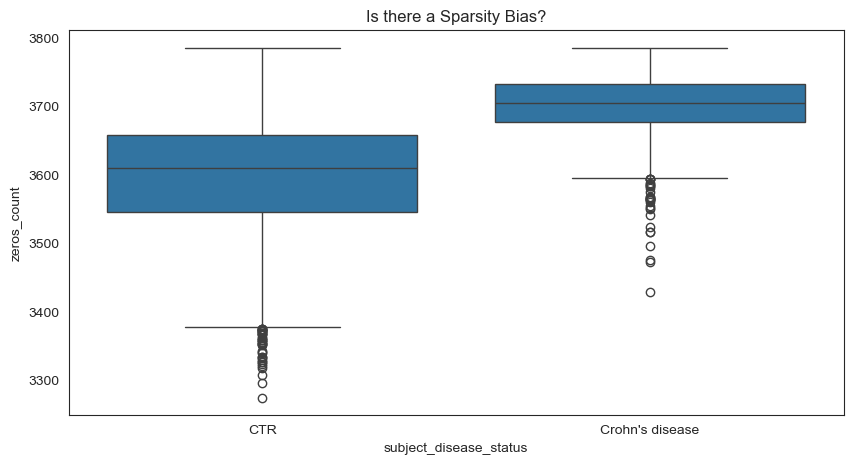

In [62]:
# Check Sparsity (Number of zeros)
df_clean['zeros_count'] = (df_clean[bacteria_cols] == 0).sum(axis=1)

plt.figure(figsize=(10, 5))
sns.boxplot(x='subject_disease_status', y='zeros_count', data=df)
plt.title("Is there a Sparsity Bias?")
plt.show()

--- DATA RANGE CHECK ---
Minimum Sum: 75.12460999999999
Maximum Sum: 100.00003
Median Sum:  96.10303000000002
------------------------



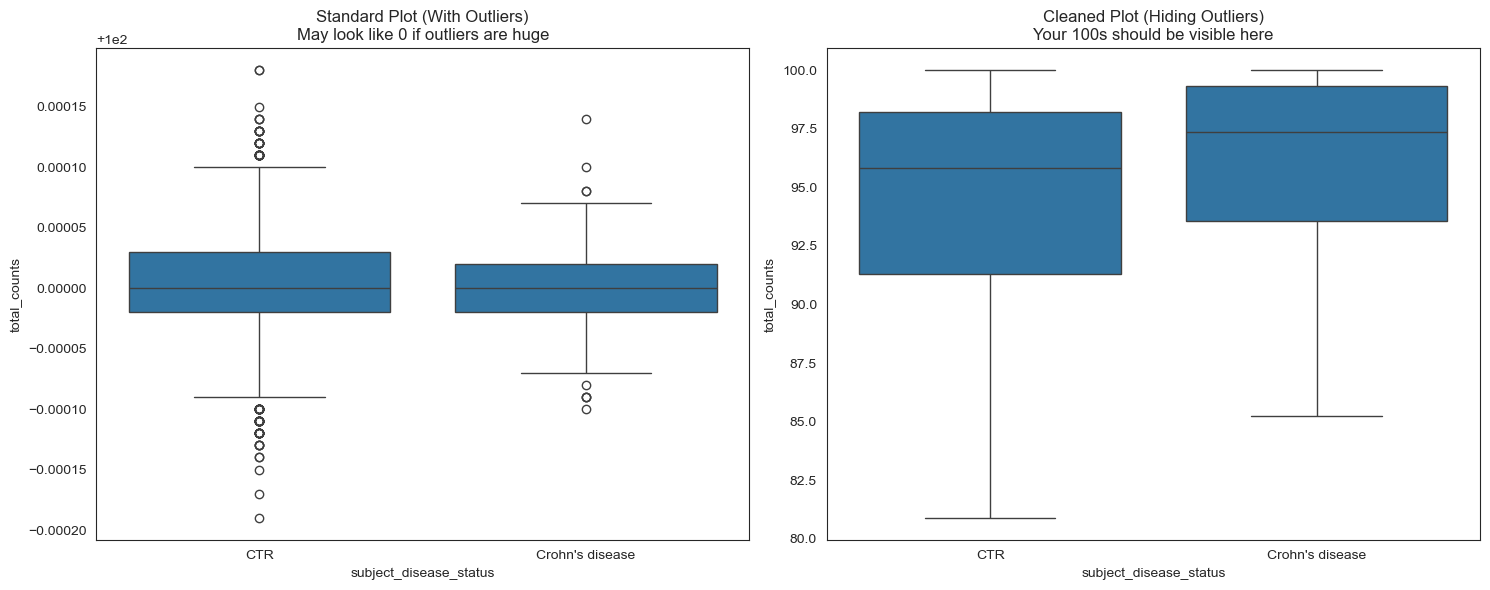

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recalculate to be 100% sure we are using the right columns
# Use the 'to_keep' species list you defined earlier for the sum
df_clean['total_counts'] = df_clean[to_keep].sum(axis=1)

# 2. Diagnostic Printout
print("--- DATA RANGE CHECK ---")
print(f"Minimum Sum: {df_clean['total_counts'].min()}")
print(f"Maximum Sum: {df_clean['total_counts'].max()}")
print(f"Median Sum:  {df_clean['total_counts'].median()}")
print("------------------------\n")

# 3. Create two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Standard boxplot (shows the squashing effect of outliers)
sns.boxplot(x='subject_disease_status', y='total_counts', data=df, ax=axes[0])
axes[0].set_title("Standard Plot (With Outliers)\nMay look like 0 if outliers are huge")

# Plot B: Boxplot hiding outliers (showfliers=False)
# This forces the Y-axis to focus on the 'normal' samples like your 100s
sns.boxplot(x='subject_disease_status', y='total_counts', data=df_clean, showfliers=False, ax=axes[1])
axes[1].set_title("Cleaned Plot (Hiding Outliers)\nYour 100s should be visible here")

plt.tight_layout()
plt.show()

In [65]:
# Extract 'Aggarwala_2020' from 'Aggarwala_2020_FMT_RCDI.sample_1001095A'
# We split by '.' and then handle the study part
df['study_id'] = df['sample_alias'].str.split('.').str[0]

# Optional: Further clean it to just the Author_Year
# This takes the first two parts joined by an underscore
df['study_id'] = df['study_id'].apply(lambda x: "_".join(x.split('_')[:2]))

print(df['study_id'].value_counts())

study_id
Lee_2023            552
Lloyd-Price_2019    497
Kumbhari_2024       288
Yachida_2019        249
Wallen_2022         234
                   ... 
SAMN05065746          1
SAMN05065760          1
SAMN05065779          1
Woodworth_2023        1
Zhao_2020             1
Name: count, Length: 327, dtype: int64


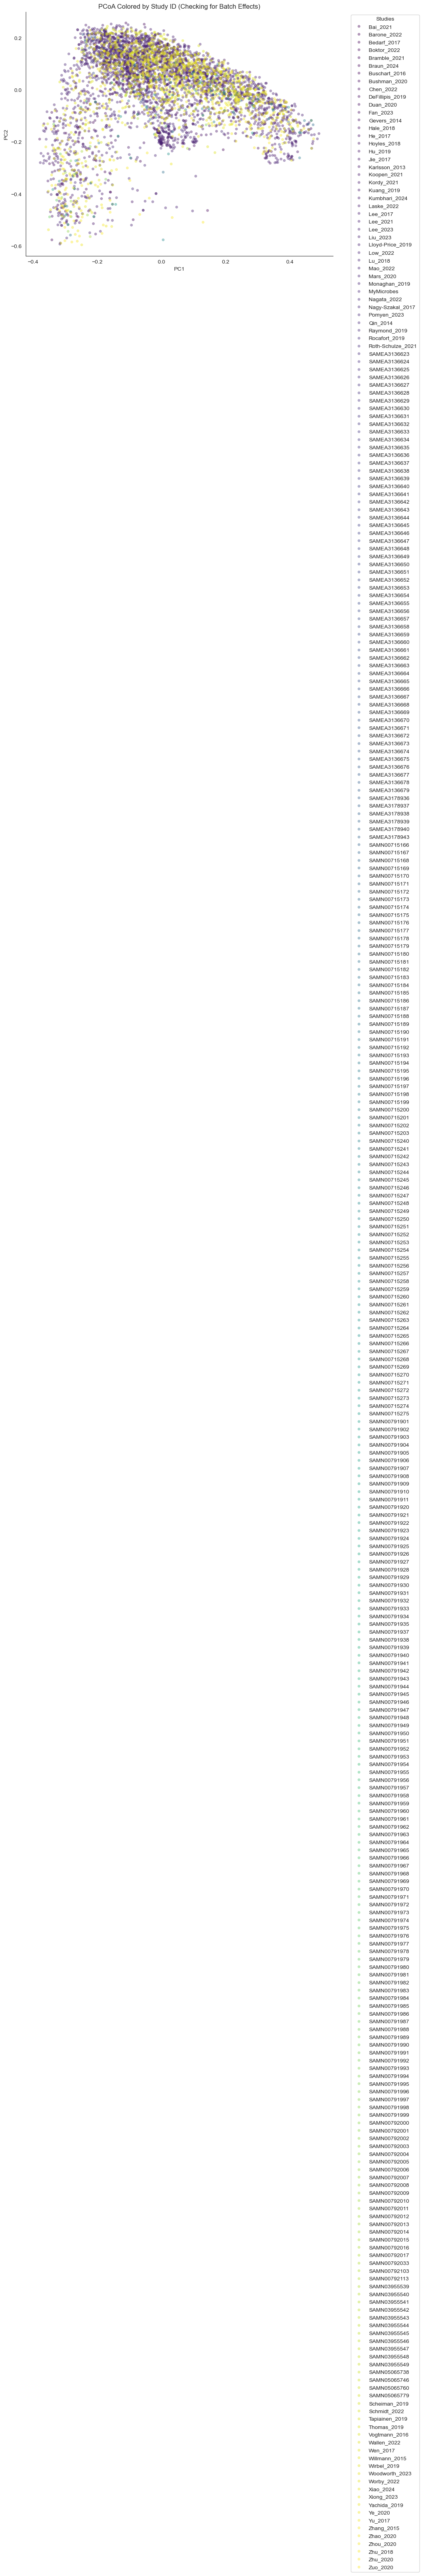

In [68]:
plt.figure(figsize=(10, 8))

# Color by Study instead of Disease
sns.scatterplot(
    data=df, 
    x='PC1', y='PC2', 
    hue='study_id', 
    palette='viridis', 
    alpha=0.4, 
    s=20,
    edgecolor=None
)

plt.title("PCoA Colored by Study ID (Checking for Batch Effects)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Studies")
sns.despine()
plt.savefig('img.png')
plt.show()